In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import xgboost as xgb
import shap


In [10]:

#  Global style 
plt.rcParams.update({
    "figure.facecolor": "#F8F9FA",
    "axes.facecolor":   "#FFFFFF",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         11,
})

SEED     = 42
np.random.seed(SEED)
print(" All libraries loaded successfully")



 All libraries loaded successfully


## 1.  Data Loading & Overview


In [11]:
df_raw = pd.read_csv("../data/credit_test.csv")
print(f"Shape         : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory usage  : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
df_raw.head(5)



Shape         : 10,353 rows × 18 columns
Memory usage  : 5.6 MB



,Loan ID,Customer ID,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,611314.0,Short Term,747.0,2074116.0,10+ years,Home Mortgage,Debt Consolidation,42000.83,21.8,NaN,9.0,0.0,621908.0,1058970.0,0.0,0.0
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,266662.0,Short Term,734.0,1919190.0,10+ years,Home Mortgage,Debt Consolidation,36624.40,19.4,NaN,11.0,0.0,679573.0,904442.0,0.0,0.0
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,153494.0,Short Term,709.0,871112.0,2 years,Rent,Debt Consolidation,8391.73,12.5,10.0,10.0,0.0,38532.0,388036.0,0.0,0.0
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,176242.0,Short Term,727.0,780083.0,10+ years,Rent,Debt Consolidation,16771.87,16.5,27.0,16.0,1.0,156940.0,531322.0,1.0,0.0
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,321992.0,Short Term,744.0,1761148.0,10+ years,Home Mortgage,Debt Consolidation,39478.77,26.0,44.0,14.0,0.0,359765.0,468072.0,0.0,0.0


In [12]:
# Column types and non-null counts
df_raw.info()



<class 'pandas.DataFrame'>
RangeIndex: 10353 entries, 0 to 10352
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loan ID                       10000 non-null  str    
 1   Customer ID                   10000 non-null  str    
 2   Current Loan Amount           10000 non-null  float64
 3   Term                          10000 non-null  str    
 4   Credit Score                  8019 non-null   float64
 5   Annual Income                 8019 non-null   float64
 6   Years in current job          9573 non-null   str    
 7   Home Ownership                10000 non-null  str    
 8   Purpose                       10000 non-null  str    
 9   Monthly Debt                  10000 non-null  float64
 10  Years of Credit History       10000 non-null  float64
 11  Months since last delinquent  4694 non-null   float64
 12  Number of Open Accounts       10000 non-null  float64
 13  Number of Cr

In [13]:
# Basic statistics for numeric columns
df_raw.describe().T.style.background_gradient(cmap="Blues", subset=["mean","std"])



,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,10000.000000,11603801.212300,31600097.140892,19470.000000,178948.000000,309276.000000,515707.500000,99999999.000000
Credit Score,8019.000000,1077.991520,1477.467761,585.000000,706.000000,725.000000,741.000000,7510.000000
Annual Income,8019.000000,1369106.039781,868755.730912,81092.000000,848340.500000,1168272.000000,1664390.500000,17815350.000000
Monthly Debt,10000.000000,18429.671699,12399.956192,0.000000,10202.857500,16052.055000,23881.337500,229057.920000
Years of Credit History,10000.000000,18.235930,7.018356,3.800000,13.600000,17.000000,21.700000,62.500000
Months since last delinquent,4694.000000,34.964636,21.640291,0.000000,17.000000,32.000000,50.000000,131.000000
Number of Open Accounts,10000.000000,11.084100,5.023380,1.000000,7.000000,10.000000,14.000000,55.000000
Number of Credit Problems,10000.000000,0.165500,0.500934,0.000000,0.000000,0.000000,0.000000,10.000000
Current Credit Balance,10000.000000,290730.063700,388168.678202,0.000000,108651.500000,207518.000000,362463.000000,16237438.000000
Maximum Open Credit,10000.000000,687130.780600,1861394.400464,0.000000,270600.000000,462605.000000,786115.000000,145907344.000000


## 2.  Data Quality & Cleaning

### 2.1 Missing Values


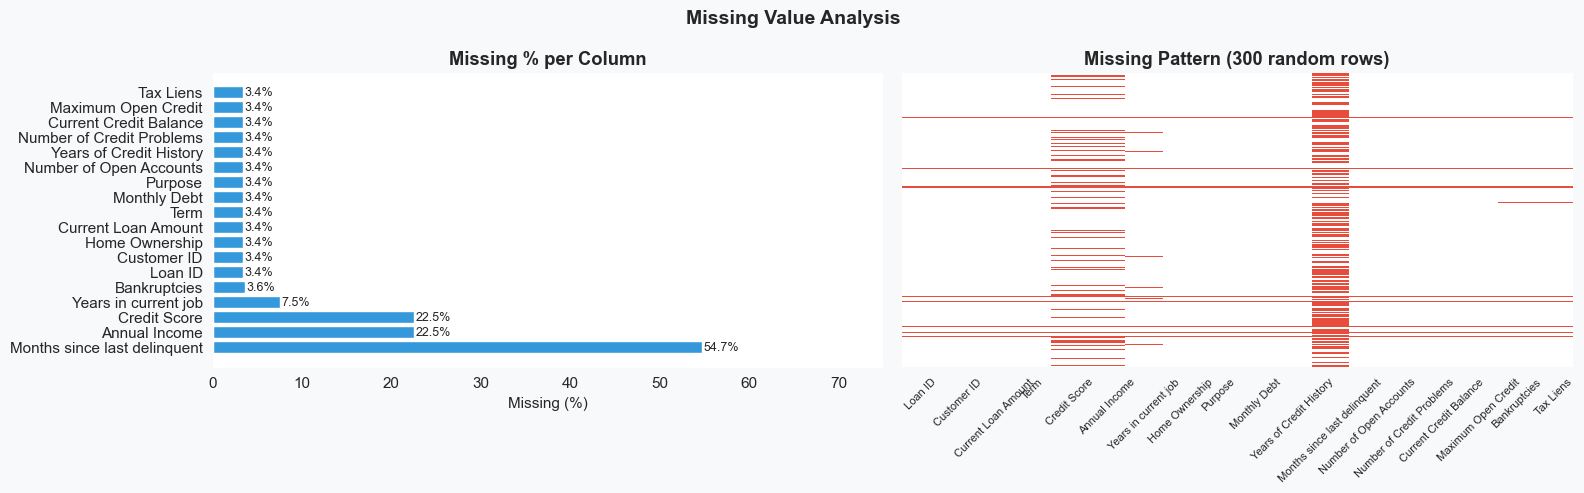

                              Missing Count  Missing %
Months since last delinquent           5659       54.7
Annual Income                          2334       22.5
Credit Score                           2334       22.5
Years in current job                    780        7.5
Bankruptcies                            375        3.6
Loan ID                                 353        3.4
Customer ID                             353        3.4
Home Ownership                          353        3.4
Current Loan Amount                     353        3.4
Term                                    353        3.4
Monthly Debt                            353        3.4
Purpose                                 353        3.4
Number of Open Accounts                 353        3.4
Years of Credit History                 353        3.4
Number of Credit Problems               353        3.4
Current Credit Balance                  353        3.4
Maximum Open Credit                     353        3.4
Tax Liens 

In [14]:
#  Missing value heatmap 
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
miss_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
miss_df = miss_df[miss_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Missing Value Analysis", fontsize=14, fontweight="bold")

# Bar chart
bars = axes[0].barh(miss_df.index, miss_df["Missing %"], color="#3498DB", edgecolor="white")
for bar, val in zip(bars, miss_df["Missing %"]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9)
axes[0].set_title("Missing % per Column", fontweight="bold")
axes[0].set_xlabel("Missing (%)")
axes[0].set_xlim(0, 75)

# Heatmap sample
sample_idx = np.random.choice(df_raw.index, 300, replace=False)
sns.heatmap(df_raw.loc[sample_idx].isnull(), ax=axes[1],
            cbar=False, yticklabels=False, cmap=["#FFFFFF","#E74C3C"])
axes[1].set_title("Missing Pattern (300 random rows)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.show()
print(miss_df.to_string())



### 2.2 Data Anomalies Detection


In [15]:
#  Anomaly 1: Credit Score — values > 850 are corrupted (e.g. 7510 → 751) 
print(" Credit Score Anomalies ")
cs = df_raw["Credit Score"]
print(f"  Total records      : {len(cs):,}")
print(f"  Non-null           : {cs.notna().sum():,}")
print(f"  Values > 850       : {(cs > 850).sum():,}  ← corrupted (10x off)")
print(f"  Max value          : {cs.max():.0f}")
print()

#  Anomaly 2: Current Loan Amount = 99,999,999 
print(" Loan Amount Anomalies ")
la = df_raw["Current Loan Amount"]
print(f"  Records = 99,999,999 : {(la == 99999999).sum():,}  ← placeholder / unknown")
print(f"  Max value            : {la.max():,.0f}")
print()

#  Anomaly 3: Purpose inconsistent casing 
print(" Purpose inconsistencies ")
print(df_raw["Purpose"].value_counts().to_string())

#  Anomaly 4: Home Ownership 'HaveMortgage' 
print()
print(" Home Ownership ")
print(df_raw["Home Ownership"].value_counts().to_string())



 Credit Score Anomalies 
  Total records      : 10,353
  Non-null           : 8,019
  Values > 850       : 453  ← corrupted (10x off)
  Max value          : 7510

 Loan Amount Anomalies 
  Records = 99,999,999 : 1,133  ← placeholder / unknown
  Max value            : 99,999,999

 Purpose inconsistencies 
Purpose
Debt Consolidation      7878
Home Improvements        593
other                    561
Other                    308
Business Loan            163
Buy a Car                142
Medical Bills            113
Buy House                 70
major_purchase            52
Take a Trip               44
small_business            31
Educational Expenses      14
moving                    14
wedding                   10
vacation                   6
renewable_energy           1

 Home Ownership 
Home Ownership
Home Mortgage    4867
Rent             4203
Own Home          914
HaveMortgage       16


### 2.3 Cleaning


In [16]:
df = df_raw.copy()

#  1. Drop ID columns (not predictive) 
df.drop(columns=["Loan ID", "Customer ID"], inplace=True)

#  2. Fix Credit Score: divide by 10 if > 850 
mask_bad_cs = df["Credit Score"] > 850
df.loc[mask_bad_cs, "Credit Score"] = (df.loc[mask_bad_cs, "Credit Score"] / 10).round(0)
# Cap remaining outliers to [300, 850]
df["Credit Score"] = df["Credit Score"].clip(300, 850)
print(f"Credit Score fixed  : {mask_bad_cs.sum():,} rows corrected")

#  3. Treat Loan Amount = 99,999,999 as missing 
df.loc[df["Current Loan Amount"] == 99999999, "Current Loan Amount"] = np.nan
print(f"Loan Amount cleaned : 99,999,999 → NaN")

#  4. Normalize Purpose casing 
df["Purpose"] = df["Purpose"].str.strip().str.lower().str.replace("_", " ").str.title()

#  5. Normalize Home Ownership 
df["Home Ownership"] = df["Home Ownership"].replace("HaveMortgage", "Home Mortgage")

#  6. Years in current job — fix "< 1 year" → 0 for numeric conversion 
job_map = {"< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3,
           "4 years": 4,  "5 years": 5, "6 years": 6, "7 years": 7,
           "8 years": 8,  "9 years": 9, "10+ years": 10}
df["Employment Years"] = df["Years in current job"].map(job_map)
df.drop(columns=["Years in current job"], inplace=True)

print()
print(" Cleaning complete")
print(f"   Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.describe().T.round(2)



Credit Score fixed  : 453 rows corrected
Loan Amount cleaned : 99,999,999 → NaN

 Cleaning complete
   Final shape: 10,353 rows × 16 columns



,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,8867.0,308786.88,183831.19,19470.0,171259.00,265958.00,430848.00,7.890960e+05
Credit Score,8019.0,716.63,28.23,585.0,704.00,723.00,739.00,7.510000e+02
Annual Income,8019.0,1369106.04,868755.73,81092.0,848340.50,1168272.00,1664390.50,1.781535e+07
Monthly Debt,10000.0,18429.67,12399.96,0.0,10202.86,16052.06,23881.34,2.290579e+05
Years of Credit History,10000.0,18.24,7.02,3.8,13.60,17.00,21.70,6.250000e+01
Months since last delinquent,4694.0,34.96,21.64,0.0,17.00,32.00,50.00,1.310000e+02
Number of Open Accounts,10000.0,11.08,5.02,1.0,7.00,10.00,14.00,5.500000e+01
Number of Credit Problems,10000.0,0.17,0.50,0.0,0.00,0.00,0.00,1.000000e+01
Current Credit Balance,10000.0,290730.06,388168.68,0.0,108651.50,207518.00,362463.00,1.623744e+07
Maximum Open Credit,10000.0,687130.78,1861394.40,0.0,270600.00,462605.00,786115.00,1.459073e+08


In [20]:
# Save cleaned data
output_dir = "../data"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "credit_cleaned.csv")

df.to_csv(csv_path, index=False)

print(f"Saved CSV     : {csv_path}")


Saved CSV     : ../data\credit_cleaned.csv
